# Exercise 7
**Cristina Correa - 1819211867**


Experiment with different epoch number different architecture
and different activation functions to find best performing model

In [1]:
import os
import matplotlib.pyplot as plt
import pandas as pd
import tensorflow as tf

from keras import layers, Model
from keras.callbacks import EarlyStopping

os.environ["KERAS_BACKEND"] = "tensorflow"

file_url = "http://storage.googleapis.com/download.tensorflow.org/data/heart.csv"
dataframe = pd.read_csv(file_url)

dataframe.shape

dataframe.head()

val_dataframe = dataframe.sample(frac=0.2, random_state=1337)
train_dataframe = dataframe.drop(val_dataframe.index)
print(
    f"Using {len(train_dataframe)} samples for training "
    f"and {len(val_dataframe)} for validation"
)


def dataframe_to_dataset(dataframe, target="target"):
    dataframe = dataframe.copy()
    labels = dataframe.pop(target)
    ds = tf.data.Dataset.from_tensor_slices((dict(dataframe), labels))
    ds = ds.shuffle(buffer_size=len(dataframe)).batch(32)
    return ds


train_ds = dataframe_to_dataset(train_dataframe)
val_ds = dataframe_to_dataset(val_dataframe)


def encode_feature(feature, name, dataset, is_string=False):
    lookup_class = layers.StringLookup if is_string else layers.IntegerLookup
    lookup = lookup_class(output_mode="binary")
    feature_ds = dataset.map(lambda x, y: x[name]).map(lambda x: tf.expand_dims(x, -1))
    lookup.adapt(feature_ds)
    return lookup(feature)


def normalize_feature(feature, name, dataset):
    normalizer = layers.Normalization()
    feature_ds = dataset.map(lambda x, y: tf.expand_dims(x[name], -1))
    normalizer.adapt(feature_ds)
    return normalizer(feature)


inputs = {
    "age": layers.Input(name="age", shape=(1,), dtype="float32"),
    "sex": layers.Input(name="sex", shape=(1,), dtype="int64"),
    "cp": layers.Input(name="cp", shape=(1,), dtype="int64"),
    "trestbps": layers.Input(name="trestbps", shape=(1,), dtype="float32"),
    "chol": layers.Input(name="chol", shape=(1,), dtype="float32"),
    "fbs": layers.Input(name="fbs", shape=(1,), dtype="int64"),
    "restecg": layers.Input(name="restecg", shape=(1,), dtype="int64"),
    "thalach": layers.Input(name="thalach", shape=(1,), dtype="float32"),
    "exang": layers.Input(name="exang", shape=(1,), dtype="int64"),
    "oldpeak": layers.Input(name="oldpeak", shape=(1,), dtype="float32"),
    "slope": layers.Input(name="slope", shape=(1,), dtype="int64"),
    "ca": layers.Input(name="ca", shape=(1,), dtype="int64"),
    "thal": layers.Input(name="thal", shape=(1,), dtype="string"),
}

encoded_features = [
    encode_feature(inputs["sex"], "sex", train_ds),
    encode_feature(inputs["cp"], "cp", train_ds),
    encode_feature(inputs["fbs"], "fbs", train_ds),
    encode_feature(inputs["restecg"], "restecg", train_ds),
    encode_feature(inputs["exang"], "exang", train_ds),
    encode_feature(inputs["ca"], "ca", train_ds),
    encode_feature(inputs["thal"], "thal", train_ds, is_string=True),
    normalize_feature(inputs["age"], "age", train_ds),
    normalize_feature(inputs["trestbps"], "trestbps", train_ds),
    normalize_feature(inputs["chol"], "chol", train_ds),
    normalize_feature(inputs["thalach"], "thalach", train_ds),
    normalize_feature(inputs["oldpeak"], "oldpeak", train_ds),
    normalize_feature(inputs["slope"], "slope", train_ds),
]

Using 242 samples for training and 61 for validation


# Experiment 1
We have different epoch numbers


Training with 10 epochs...
Epoch 1/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 70ms/step - accuracy: 0.6839 - loss: 0.6429 - val_accuracy: 0.7869 - val_loss: 0.5836
Epoch 2/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7338 - loss: 0.6002 - val_accuracy: 0.7705 - val_loss: 0.5451
Epoch 3/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7352 - loss: 0.5425 - val_accuracy: 0.7705 - val_loss: 0.5121
Epoch 4/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7790 - loss: 0.5065 - val_accuracy: 0.7705 - val_loss: 0.4841
Epoch 5/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7455 - loss: 0.5007 - val_accuracy: 0.7705 - val_loss: 0.4635
Epoch 6/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7313 - loss: 0.4804 - val_accuracy: 0.7705 - val_loss: 0.4443
Epoch 7/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7636 - loss: 0.4413 - val_accuracy: 0.7705 - val_loss: 0.4296
Epoch 8/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7644 - loss: 0.4276 - val_accuracy: 0.770

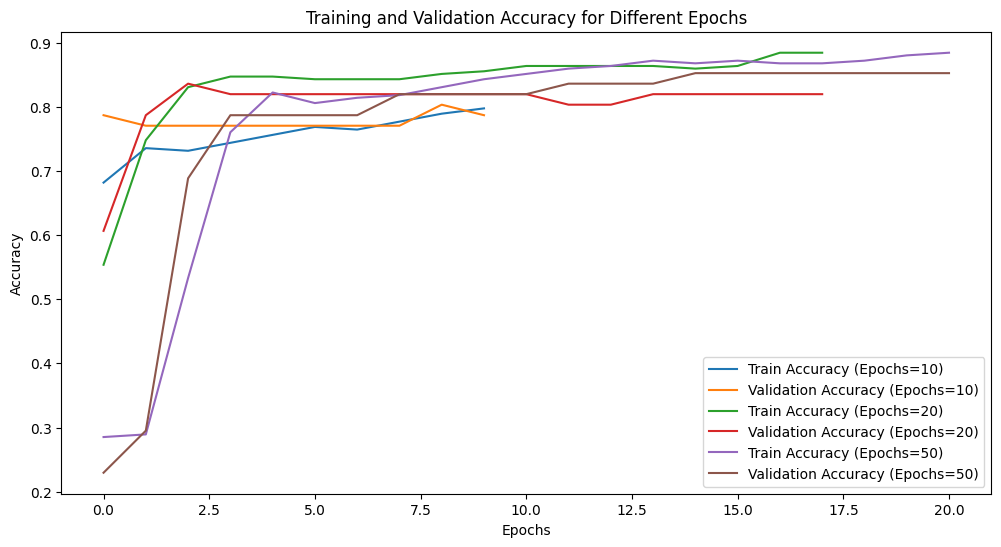

In [2]:
def build_model():
    all_features = layers.concatenate(encoded_features)
    x = layers.Dense(32, activation="relu")(all_features)
    x = layers.Dense(16, activation="relu")(x)
    output = layers.Dense(1, activation="sigmoid")(x)
    model = Model(inputs, output)
    model.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])
    return model


epoch_list = [10, 20, 50]
results = {}

for epochs in epoch_list:
    print(f"\nTraining with {epochs} epochs...")
    model = build_model()
    early_stopping = EarlyStopping(
        monitor="val_loss", patience=5, restore_best_weights=True
    )
    history = model.fit(
        train_ds, epochs=epochs, validation_data=val_ds, callbacks=[early_stopping]
    )

    results[epochs] = history.history

plt.figure(figsize=(12, 6))
for epochs, history in results.items():
    plt.plot(history["accuracy"], label=f"Train Accuracy (Epochs={epochs})")
    plt.plot(history["val_accuracy"], label=f"Validation Accuracy (Epochs={epochs})")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.title("Training and Validation Accuracy for Different Epochs")
plt.show()

---------
# Experiment 2
We have different epoch architectures


Experiment 1: {'num_layers': 1, 'units_per_layer': 32, 'activation': 'relu', 'dropout_rate': 0.0}


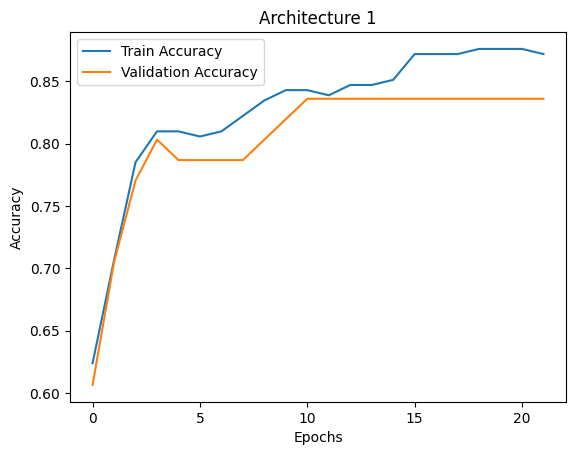


Experiment 2: {'num_layers': 2, 'units_per_layer': 64, 'activation': 'relu', 'dropout_rate': 0.2}


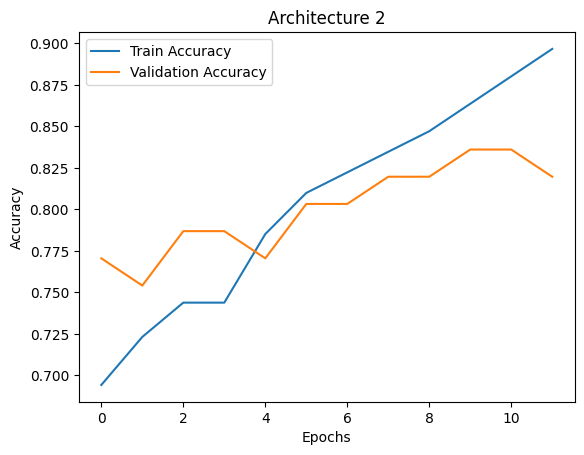


Experiment 3: {'num_layers': 3, 'units_per_layer': 128, 'activation': 'tanh', 'dropout_rate': 0.3}


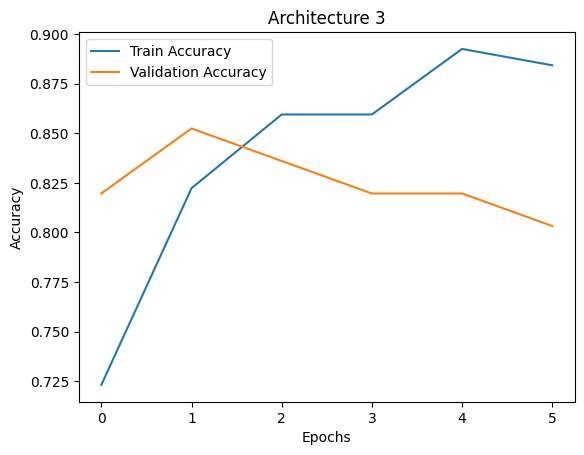

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 318ms/step
This patient has a 48.3% probability of heart disease.


In [3]:
def build_model(num_layers=1, units_per_layer=32, activation="relu", dropout_rate=0.0):
    all_features = layers.concatenate(encoded_features)
    x = all_features
    
    for _ in range(num_layers):
        x = layers.Dense(units_per_layer, activation=activation)(x)
        if dropout_rate > 0.0:
            x = layers.Dropout(dropout_rate)(x)
    output = layers.Dense(1, activation="sigmoid")(x)

    model = Model(inputs, output)
    model.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])
    return model


architectures = [
    {"num_layers": 1, "units_per_layer": 32, "activation": "relu", "dropout_rate": 0.0},
    {"num_layers": 2, "units_per_layer": 64, "activation": "relu", "dropout_rate": 0.2},
    {
        "num_layers": 3,
        "units_per_layer": 128,
        "activation": "tanh",
        "dropout_rate": 0.3,
    },
]

for idx, arch in enumerate(architectures, start=1):
    print(f"\nExperiment {idx}: {arch}")
    model = build_model(**arch)

    early_stopping = EarlyStopping(
        monitor="val_loss", patience=5, restore_best_weights=True
    )

    history = model.fit(
        train_ds,
        epochs=50,
        validation_data=val_ds,
        callbacks=[early_stopping],
        verbose=0,  
    )

    plt.plot(history.history["accuracy"], label="Train Accuracy")
    plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
    plt.title(f"Architecture {idx}")
    plt.xlabel("Epochs")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.show()



sample = {
    "age": 60,
    "sex": 1,
    "cp": 1,
    "trestbps": 145,
    "chol": 233,
    "fbs": 1,
    "restecg": 2,
    "thalach": 150,
    "exang": 0,
    "oldpeak": 2.3,
    "slope": 3,
    "ca": 0,
    "thal": "fixed",
}

input_dict = {name: tf.convert_to_tensor([value]) for name, value in sample.items()}
predictions = model.predict(input_dict)

print(
    f"This patient has a {100 * predictions[0][0]:.1f}% probability of heart disease."
)

--------------
# Experiment 3
We have different activation functions

Training with activation function: relu
Epoch 1/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 54ms/step - accuracy: 0.3907 - loss: 0.7587 - val_accuracy: 0.7049 - val_loss: 0.6210
Epoch 2/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6829 - loss: 0.6051 - val_accuracy: 0.7705 - val_loss: 0.5142
Epoch 3/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7596 - loss: 0.5055 - val_accuracy: 0.7869 - val_loss: 0.4537
Epoch 4/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7474 - loss: 0.4616 - val_accuracy: 0.7541 - val_loss: 0.4176
Epoch 5/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8320 - loss: 0.4006 - val_accuracy: 0.7705 - val_loss: 0.3966
Epoch 6/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8466 - loss: 0.3351 - val_accuracy: 0.8033 - val_loss: 0.3853
Epoch 7/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8681 - loss: 0.3292 - val_accuracy: 0.8197 - val_loss: 0.3804
Epoch 8/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8696 - loss: 0.2965 - val_acc

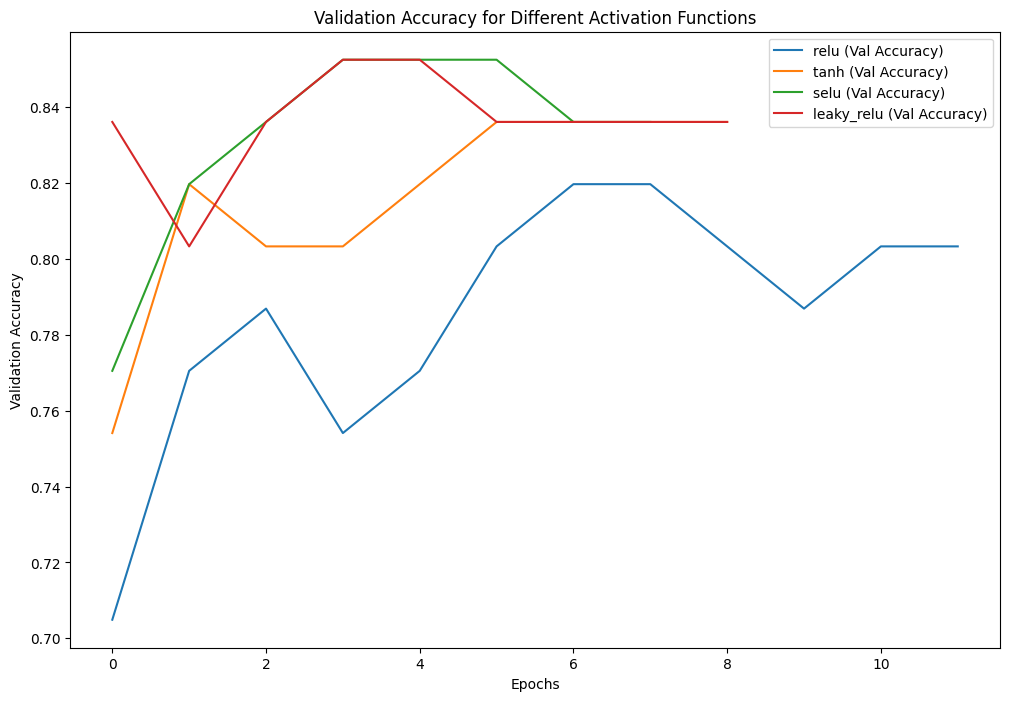

In [4]:
def build_model(activation_function="relu"):
    all_features = layers.concatenate(encoded_features)
    x = layers.Dense(64, activation=activation_function)(all_features)
    x = layers.Dense(32, activation=activation_function)(x)
    output = layers.Dense(1, activation="sigmoid")(x)

    model = Model(inputs, output)
    model.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])
    return model


activation_functions = ["relu", "tanh", "selu", "leaky_relu"]

results = {}

for activation in activation_functions:
    print(f"Training with activation function: {activation}")
    if activation == "leaky_relu":
        activation_layer = layers.LeakyReLU()  # Leaky ReLU requires a layer

        def build_model_with_leaky_relu():
            all_features = layers.concatenate(encoded_features)
            x = layers.Dense(64)(all_features)
            x = activation_layer(x)
            x = layers.Dense(32)(x)
            x = activation_layer(x)
            output = layers.Dense(1, activation="sigmoid")(x)
            model = Model(inputs, output)
            model.compile(
                optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"]
            )
            return model

        model = build_model_with_leaky_relu()
    else:
        model = build_model(activation_function=activation)

    early_stopping = EarlyStopping(
        monitor="val_loss", patience=5, restore_best_weights=True
    )
    history = model.fit(
        train_ds, epochs=50, validation_data=val_ds, callbacks=[early_stopping]
    )

    results[activation] = history

plt.figure(figsize=(12, 8))
for activation, history in results.items():
    plt.plot(history.history["val_accuracy"], label=f"{activation} (Val Accuracy)")
plt.xlabel("Epochs")
plt.ylabel("Validation Accuracy")
plt.legend()
plt.title("Validation Accuracy for Different Activation Functions")
plt.show()